# Part 1h: Data Augmentation with KerasCV

This notebook demonstrates modern image augmentation techniques using KerasCV.

## Topics Covered:
1. Basic KerasCV Augmentations
2. RandAugment
3. CutMix and MixUp
4. Augmentation Pipelines
5. A/B Testing Augmentation Impact

**Author:** Advanced Deep Learning Course Assignment

In [1]:
# Install KerasCV
!pip install keras-cv -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 34.4 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_cv
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"KerasCV version: {keras_cv.__version__}")

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0
KerasCV version: 0.9.0


In [3]:
# Load CIFAR-10 dataset (better for demonstrating image augmentation)
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Squeeze labels
y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Use subset for faster training
X_train = X_train[:10000]
y_train = y_train[:10000]

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training data: (10000, 32, 32, 3)
Test data: (10000, 32, 32, 3)


In [4]:
# Helper function to visualize augmentations
def visualize_augmentation(images, augmentation_layer, title, n_samples=5):
    """
    Visualize original images and their augmented versions.
    """
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))
    fig.suptitle(title, fontsize=14)

    for i in range(n_samples):
        # Original image
        axes[0, i].imshow(images[i])
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        # Augmented image
        augmented = augmentation_layer(tf.expand_dims(images[i], 0))
        augmented = tf.clip_by_value(augmented, 0, 1)
        axes[1, i].imshow(augmented[0])
        axes[1, i].set_title('Augmented')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

---
## 1. Basic KerasCV Augmentations

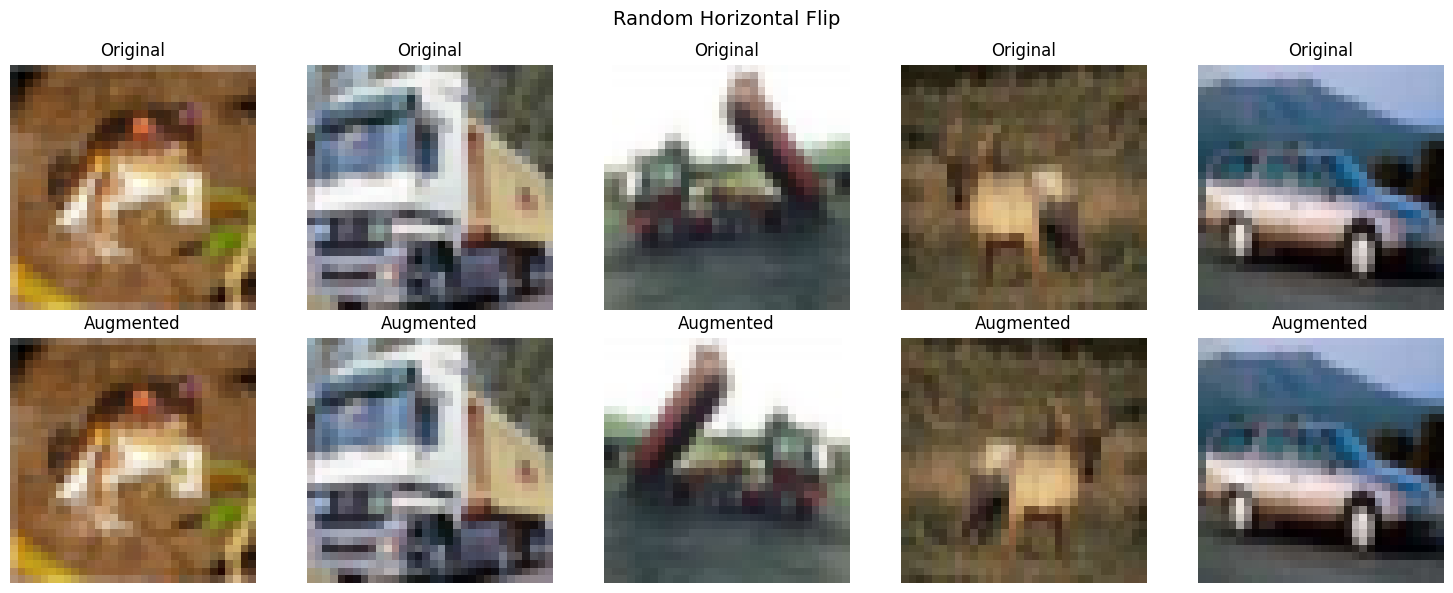

In [5]:
# Random Flip
random_flip = keras_cv.layers.RandomFlip(mode='horizontal')
visualize_augmentation(X_train[:5], random_flip, 'Random Horizontal Flip')

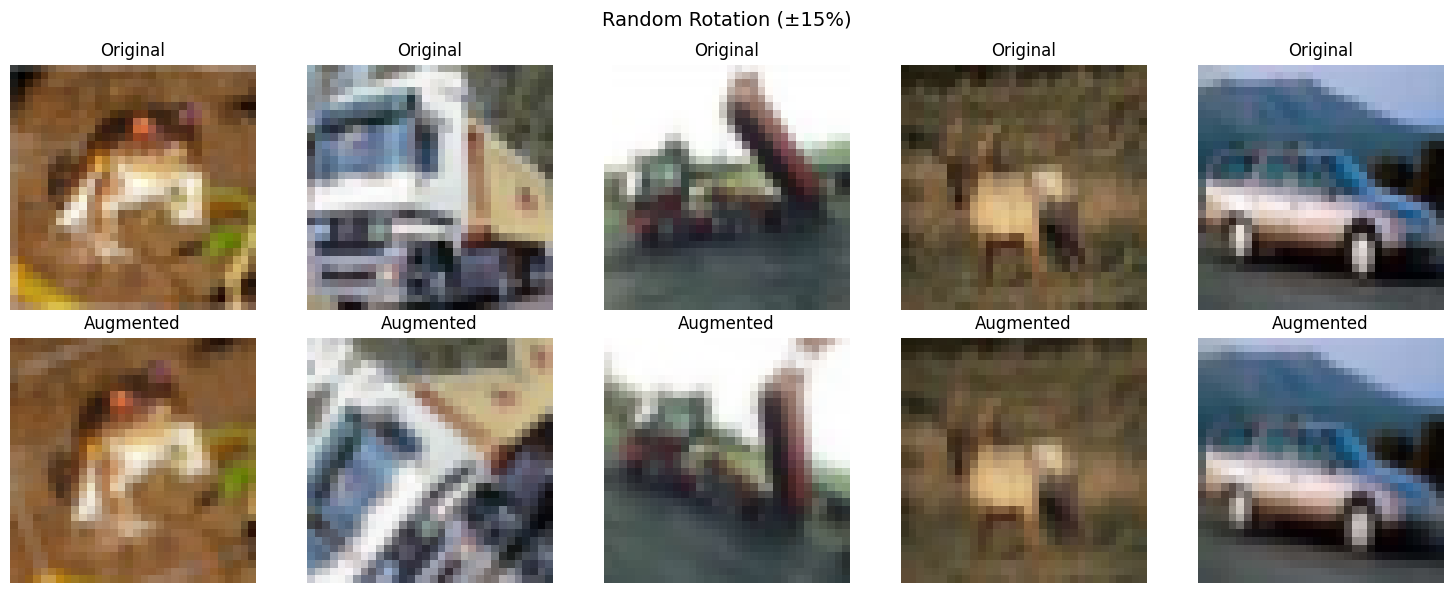

In [6]:
# Random Rotation
random_rotation = keras_cv.layers.RandomRotation(factor=0.15)
visualize_augmentation(X_train[:5], random_rotation, 'Random Rotation (±15%)')

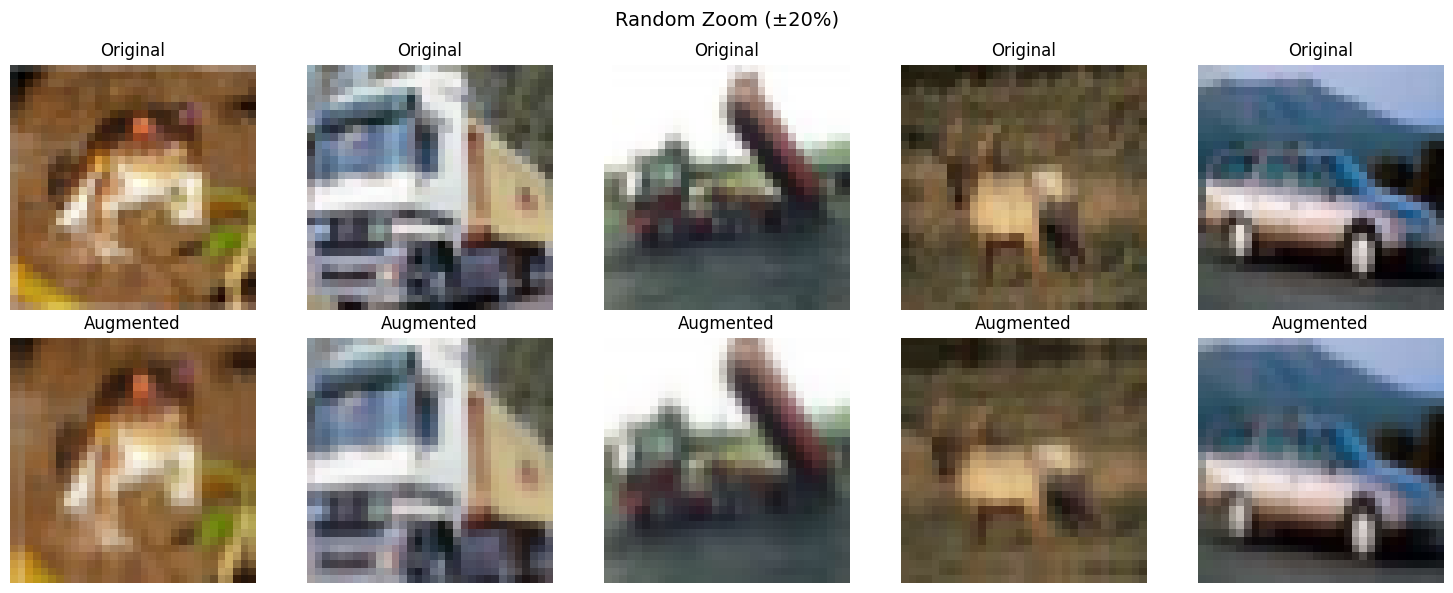

In [7]:
# Random Zoom
random_zoom = keras_cv.layers.RandomZoom(height_factor=0.2, width_factor=0.2)
visualize_augmentation(X_train[:5], random_zoom, 'Random Zoom (±20%)')

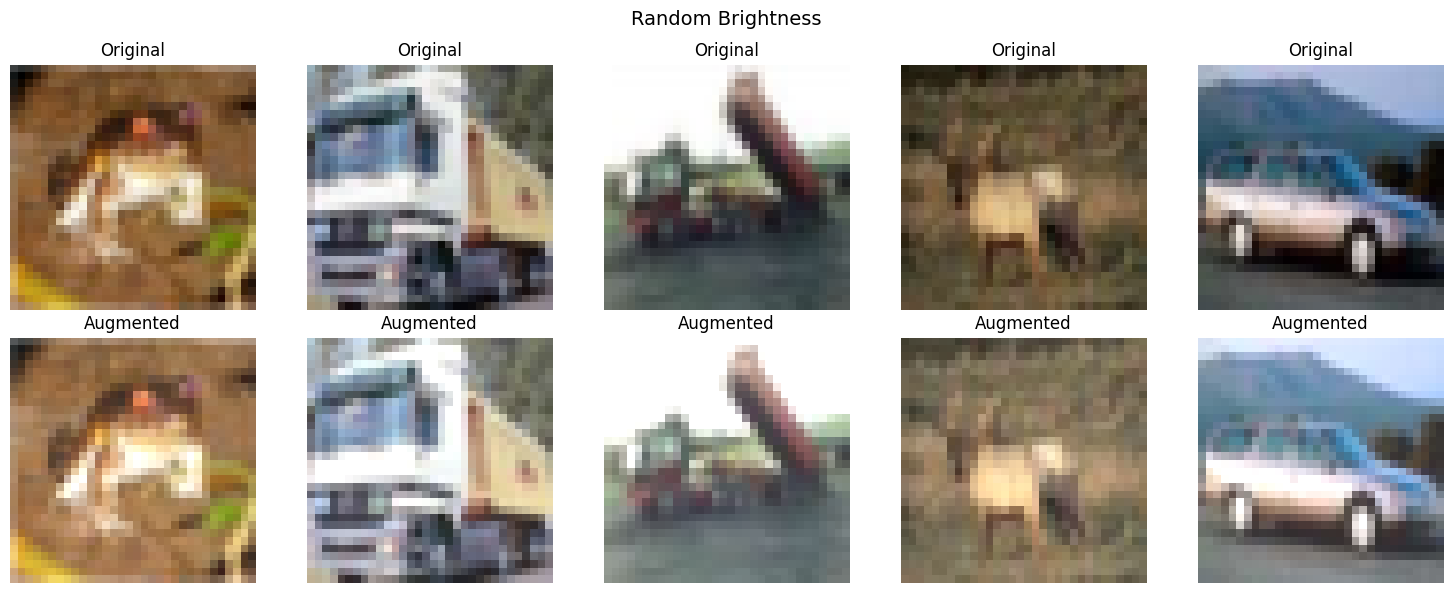

In [8]:
# Random Brightness
random_brightness = keras_cv.layers.RandomBrightness(factor=0.3, value_range=(0, 1))
visualize_augmentation(X_train[:5], random_brightness, 'Random Brightness')

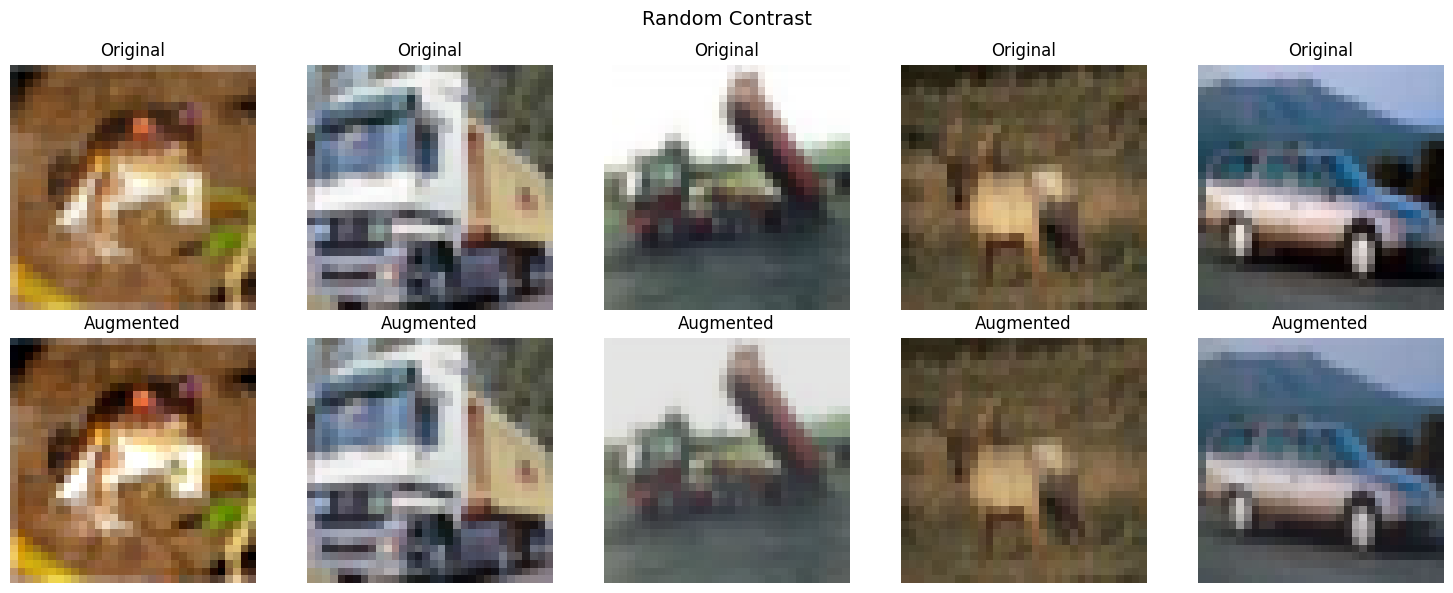

In [9]:
# Random Contrast
random_contrast = keras_cv.layers.RandomContrast(factor=0.3, value_range=(0, 1))
visualize_augmentation(X_train[:5], random_contrast, 'Random Contrast')

---
## 2. Advanced Augmentations

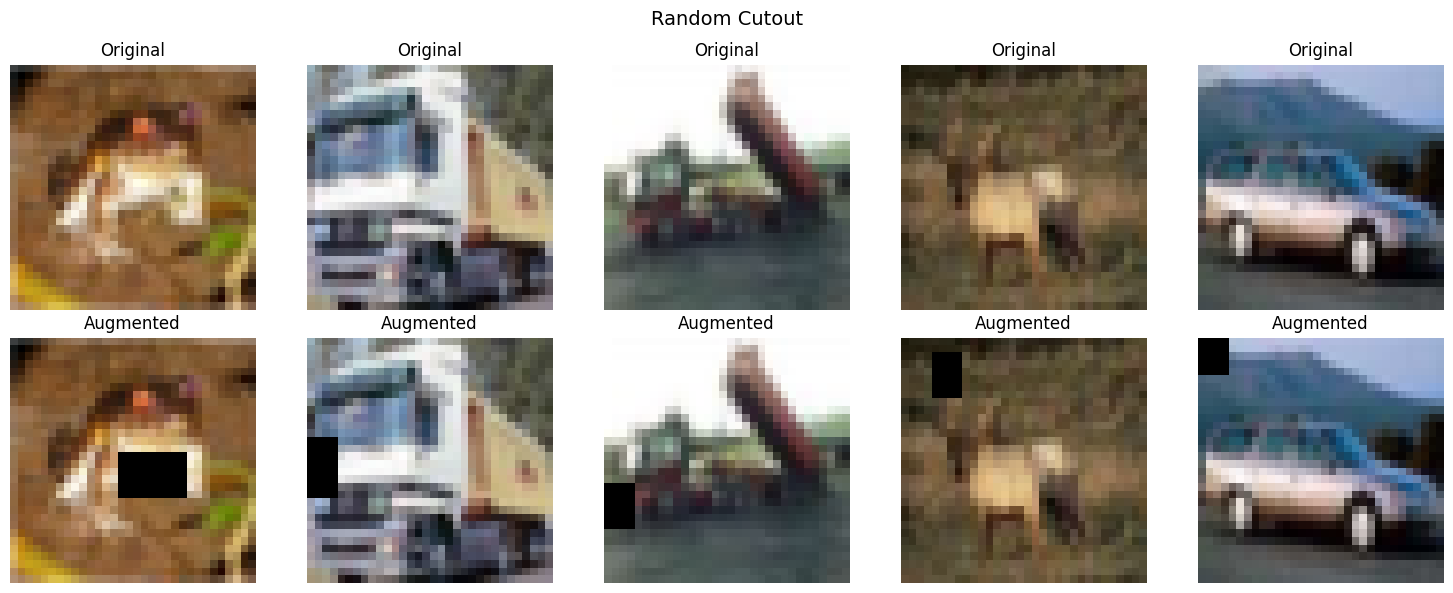

In [10]:
# Random Cutout (Erasing)
random_cutout = keras_cv.layers.RandomCutout(
    height_factor=0.3,
    width_factor=0.3
)
visualize_augmentation(X_train[:5], random_cutout, 'Random Cutout')

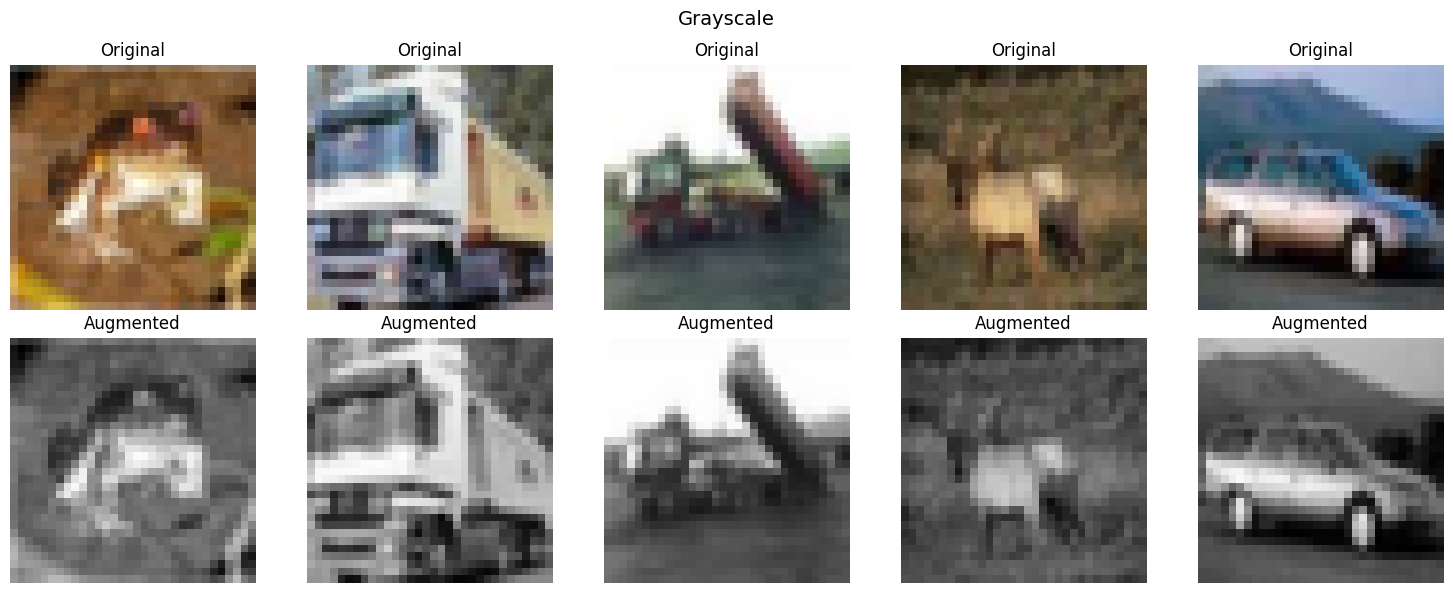

In [11]:
# Grayscale Transform
grayscale = keras_cv.layers.Grayscale(output_channels=3)
visualize_augmentation(X_train[:5], grayscale, 'Grayscale')

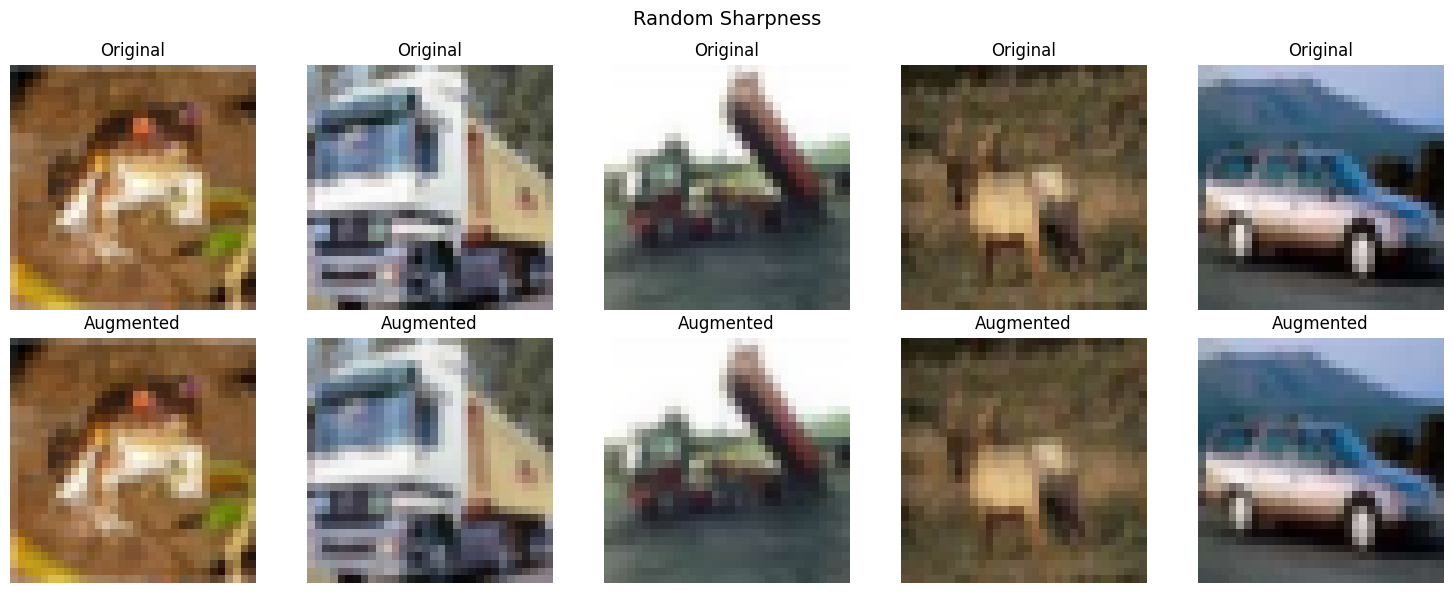

In [12]:
# Random Sharpness
random_sharpness = keras_cv.layers.RandomSharpness(factor=0.5, value_range=(0, 1))
visualize_augmentation(X_train[:5], random_sharpness, 'Random Sharpness')

---
## 3. RandAugment

RandAugment automatically selects and applies a sequence of augmentations.

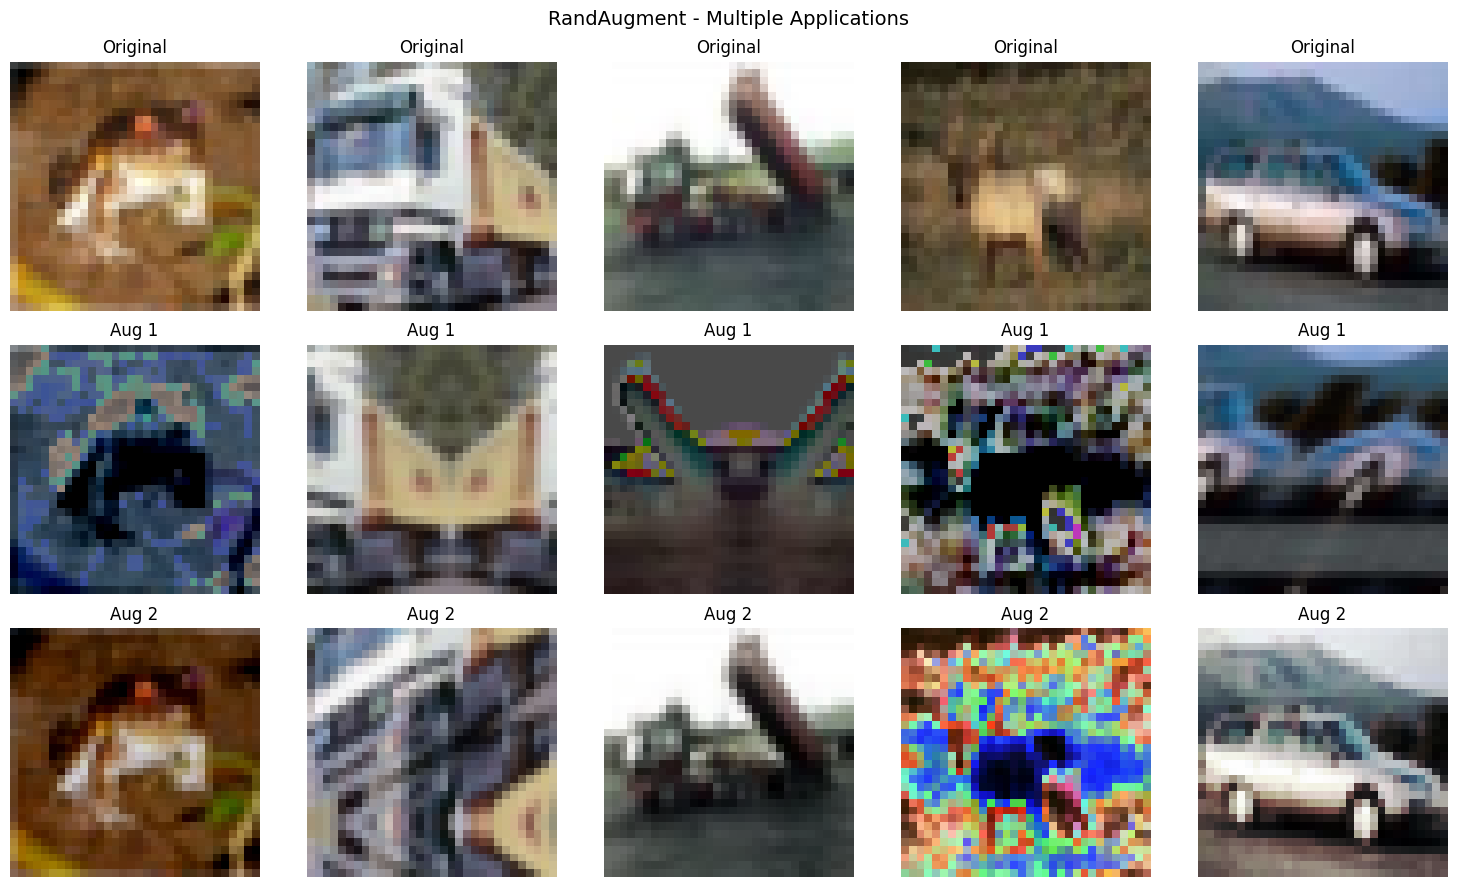

In [13]:
# RandAugment
rand_augment = keras_cv.layers.RandAugment(
    value_range=(0, 1),
    augmentations_per_image=3,   # Number of augmentations to apply
    magnitude=0.5                 # Strength of augmentations
)

# Visualize multiple applications
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('RandAugment - Multiple Applications', fontsize=14)

for row in range(3):
    for col in range(5):
        if row == 0:
            axes[row, col].imshow(X_train[col])
            axes[row, col].set_title('Original')
        else:
            augmented = rand_augment(tf.expand_dims(X_train[col], 0))
            augmented = tf.clip_by_value(augmented, 0, 1)
            axes[row, col].imshow(augmented[0])
            axes[row, col].set_title(f'Aug {row}')
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

---
## 4. CutMix and MixUp

These are regularization techniques that combine training examples.

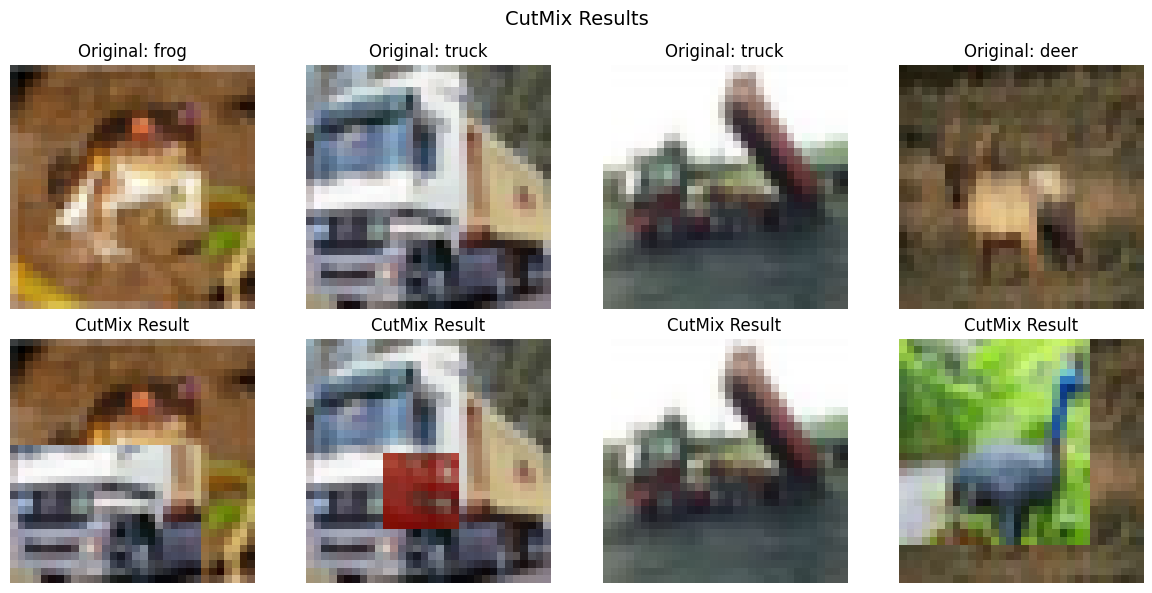

In [14]:
# CutMix - cuts and pastes patches between images
cut_mix = keras_cv.layers.CutMix(alpha=1.0)

# Create batched input (CutMix works on batches)
# Convert to tensors (required for newer KerasCV versions)
batch_images = tf.constant(X_train[:8])
batch_labels = tf.one_hot(y_train[:8], 10)

# Apply CutMix
cutmix_result = cut_mix({'images': batch_images, 'labels': batch_labels})

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('CutMix Results', fontsize=14)

for i in range(4):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title(f'Original: {class_names[y_train[i]]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(tf.clip_by_value(cutmix_result['images'][i], 0, 1))
    axes[1, i].set_title('CutMix Result')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

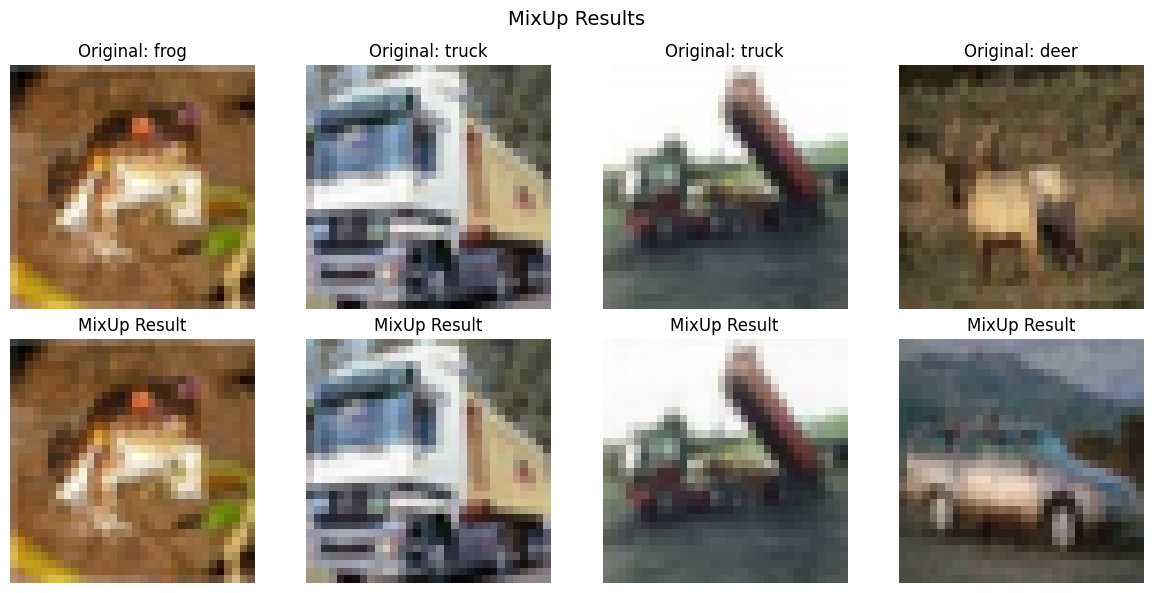

In [15]:
# MixUp - blends images and labels
mix_up = keras_cv.layers.MixUp(alpha=0.4)

# Apply MixUp (using tensors from previous cell)
mixup_result = mix_up({'images': batch_images, 'labels': batch_labels})

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('MixUp Results', fontsize=14)

for i in range(4):
    axes[0, i].imshow(X_train[i])
    axes[0, i].set_title(f'Original: {class_names[y_train[i]]}')
    axes[0, i].axis('off')

    axes[1, i].imshow(tf.clip_by_value(mixup_result['images'][i], 0, 1))
    axes[1, i].set_title('MixUp Result')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

---
## 5. Building Augmentation Pipelines

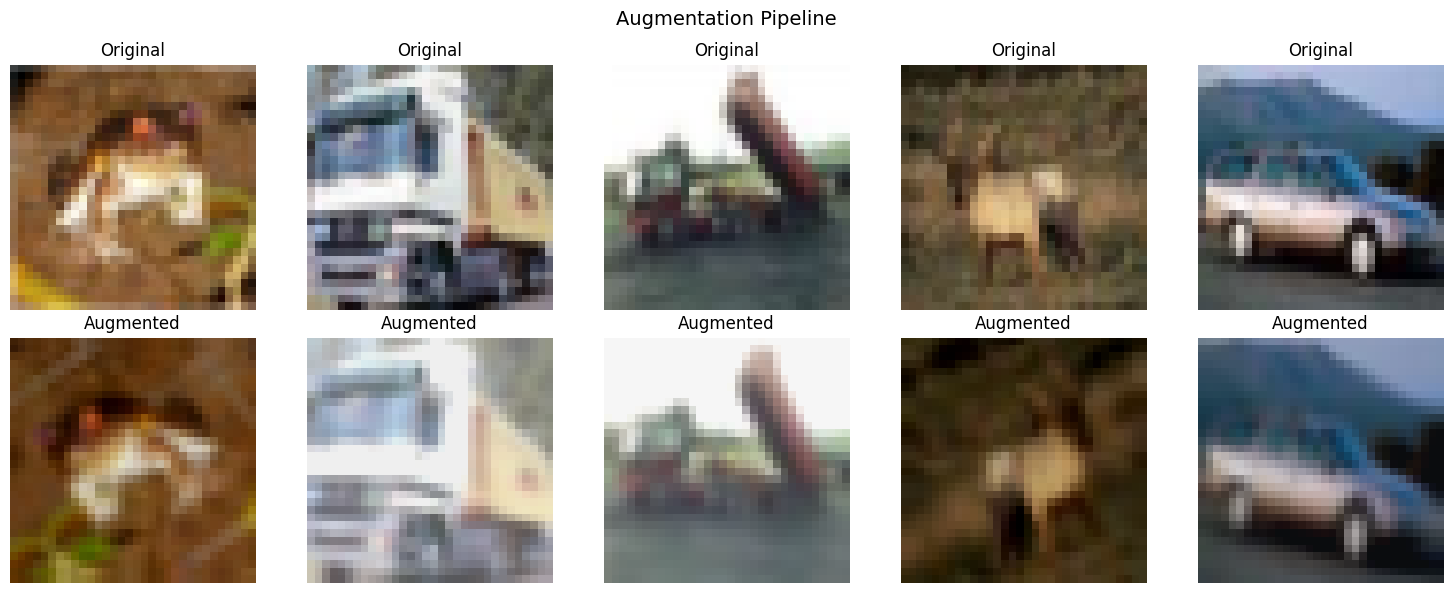

In [16]:
# Create a comprehensive augmentation pipeline
augmentation_pipeline = keras.Sequential([
    keras_cv.layers.RandomFlip(mode='horizontal'),
    keras_cv.layers.RandomRotation(factor=0.1),
    keras_cv.layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    keras_cv.layers.RandomBrightness(factor=0.2, value_range=(0, 1)),
    keras_cv.layers.RandomContrast(factor=0.2, value_range=(0, 1)),
], name='augmentation_pipeline')

# Visualize pipeline results
visualize_augmentation(X_train[:5], augmentation_pipeline, 'Augmentation Pipeline')

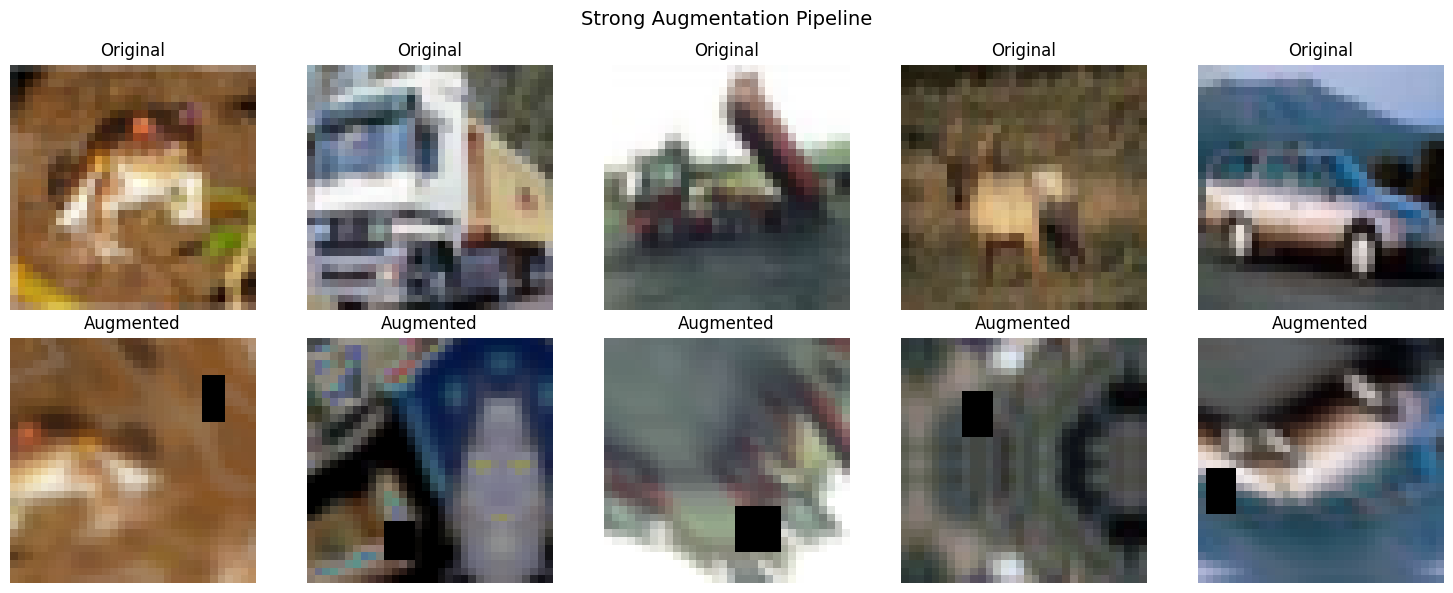

In [17]:
# Strong augmentation pipeline (for SSL or robust training)
strong_augmentation = keras.Sequential([
    keras_cv.layers.RandomFlip(mode='horizontal_and_vertical'),
    keras_cv.layers.RandomRotation(factor=0.2),
    keras_cv.layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    keras_cv.layers.RandAugment(value_range=(0, 1), augmentations_per_image=2, magnitude=0.5),
    keras_cv.layers.RandomCutout(height_factor=0.2, width_factor=0.2),
], name='strong_augmentation')

visualize_augmentation(X_train[:5], strong_augmentation, 'Strong Augmentation Pipeline')

---
## 6. A/B Testing: Augmentation Impact

In [18]:
def create_cnn_model():
    """Create a simple CNN for CIFAR-10."""
    model = keras.Sequential([
        layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [19]:
# Train WITHOUT augmentation (baseline)
print("Training WITHOUT augmentation (baseline)...")
model_no_aug = create_cnn_model()

history_no_aug = model_no_aug.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

test_loss_no_aug, test_acc_no_aug = model_no_aug.evaluate(X_test, y_test, verbose=0)
print(f"Baseline Test Accuracy: {test_acc_no_aug:.4f}")

Training WITHOUT augmentation (baseline)...
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.1695 - loss: 2.2326 - val_accuracy: 0.1075 - val_loss: 2.3920
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1940 - loss: 2.0361 - val_accuracy: 0.2305 - val_loss: 2.0135
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2119 - loss: 1.9710 - val_accuracy: 0.2785 - val_loss: 1.8916
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2304 - loss: 1.9229 - val_accuracy: 0.2950 - val_loss: 1.7976
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2404 - loss: 1.9024 - val_accuracy: 0.3655 - val_loss: 1.7185
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2656 - loss: 1.8703 - val_accuracy: 0.2855 - val_loss: 1.9283
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2730 - loss: 1.8404 - val_accuracy: 0.4025 - val_loss: 1.6217
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accu

In [20]:
# Train WITH augmentation
print("\nTraining WITH augmentation...")

# Create augmented dataset
def create_augmented_dataset(images, labels, augmentation, batch_size=32):
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.shuffle(1000)
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(
        lambda x, y: (augmentation(x, training=True), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

# Split data
split_idx = int(0.8 * len(X_train))
X_train_split = X_train[:split_idx]
y_train_split = y_train[:split_idx]
X_val_split = X_train[split_idx:]
y_val_split = y_train[split_idx:]

# Create datasets
train_dataset = create_augmented_dataset(X_train_split, y_train_split, augmentation_pipeline)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_split, y_val_split)).batch(32)

# Train model
model_with_aug = create_cnn_model()

history_with_aug = model_with_aug.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    verbose=1
)

test_loss_with_aug, test_acc_with_aug = model_with_aug.evaluate(X_test, y_test, verbose=0)
print(f"With Augmentation Test Accuracy: {test_acc_with_aug:.4f}")


Training WITH augmentation...
Epoch 1/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.1238 - loss: 2.3025 - val_accuracy: 0.1545 - val_loss: 2.2274
Epoch 2/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1435 - loss: 2.1823 - val_accuracy: 0.1715 - val_loss: 2.0850
Epoch 3/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1552 - loss: 2.1302 - val_accuracy: 0.2295 - val_loss: 2.0539
Epoch 4/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1653 - loss: 2.1006 - val_accuracy: 0.2115 - val_loss: 1.9536
Epoch 5/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1729 - loss: 2.1028 - val_accuracy: 0.2400 - val_loss: 1.9634
Epoch 6/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1711 - loss: 2.0861 - val_accuracy: 0.2850 - val_loss: 1.9109
Epoch 7/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1733 - loss: 2.0767 - val_accuracy: 0.2835 - val_loss: 1.8687
Epoch 8/15
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1739 -

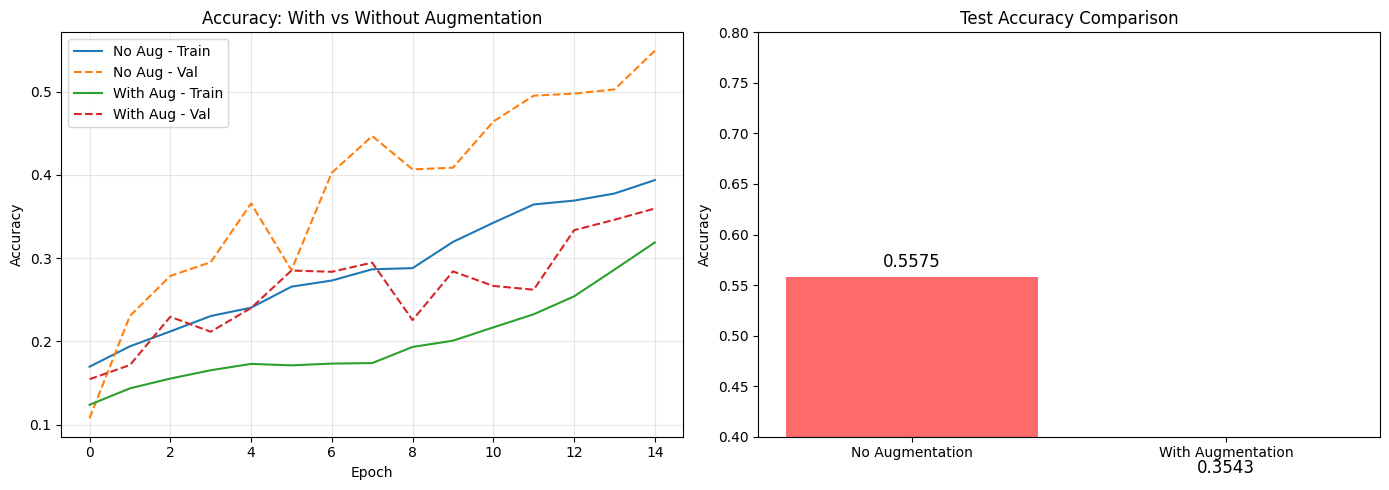


Improvement with augmentation: -20.32%


In [21]:
# Compare results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_no_aug.history['accuracy'], label='No Aug - Train')
axes[0].plot(history_no_aug.history['val_accuracy'], '--', label='No Aug - Val')
axes[0].plot(history_with_aug.history['accuracy'], label='With Aug - Train')
axes[0].plot(history_with_aug.history['val_accuracy'], '--', label='With Aug - Val')
axes[0].set_title('Accuracy: With vs Without Augmentation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test accuracy comparison
accuracies = [test_acc_no_aug, test_acc_with_aug]
labels = ['No Augmentation', 'With Augmentation']
colors = ['#ff6b6b', '#4ecdc4']

bars = axes[1].bar(labels, accuracies, color=colors)
axes[1].set_title('Test Accuracy Comparison')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.4, 0.8)

for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, acc + 0.01,
                f'{acc:.4f}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nImprovement with augmentation: {(test_acc_with_aug - test_acc_no_aug)*100:.2f}%")

---
## Summary

### KerasCV Augmentation Layers:

| Layer | Effect | Use Case |
|-------|--------|----------|
| `RandomFlip` | Horizontal/vertical flip | Most image tasks |
| `RandomRotation` | Random rotation | Rotation-invariant tasks |
| `RandomZoom` | Random zoom in/out | Scale-invariant tasks |
| `RandomBrightness` | Adjust brightness | Lighting variations |
| `RandomContrast` | Adjust contrast | Lighting variations |
| `RandomCutout` | Random erasing | Occlusion robustness |
| `RandAugment` | Auto augmentation | General purpose |
| `CutMix` | Cut and paste patches | Regularization |
| `MixUp` | Blend images | Regularization |

### Best Practices:
1. Start with basic augmentations (flip, rotation)
2. Add color augmentations for real-world robustness
3. Use RandAugment for automatic augmentation
4. CutMix/MixUp improve generalization significantly
5. Always validate augmentation improves performance